<h1><center>EKSPLORASI DERET WAKTU</center></h1>
<h3><center>Studi Kasus: Konsumsi Listrik Bulanan (Jan 2013 – Nov 2023)</center></h3>

<center>
_____________________________________________________________________________________________________________________________
</center>

**Tujuan pembelajaran**

1. Melakukan pemeriksaan awal (struktur data, *missing value*, duplikat, tipe data) pada deret waktu.
2. Mengeksplorasi deret secara visual: plot deret, plot musiman, *boxplot*, *heatmap*, *lag plot*.
3. Memeriksa **kestasioneran dalam nilai tengah** melalui plot ACF/PACF, uji ADF, uji PP, dan uji KPSS.
4. Memeriksa **kestasioneran dalam ragam** melalui transformasi Box-Cox.
5. Menguraikan deret menjadi komponen tren, musiman, dan sisaan (dekomposisi klasik dan STL).
6. Menangani ketidakstasioneran melalui **transformasi Box-Cox** dan **pembedaan (differencing)** reguler maupun musiman.

## 1. Persiapan Lingkungan Kerja

Jalankan sel di bawah **hanya sekali** (khususnya jika bekerja di Google Colab).

In [1]:
# Install paket pendukung
!pip install PythonTsa -q
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 7.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from scipy.stats import boxcox, boxcox_llf, boxcox_normmax

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

Paket `PythonTsa` menyediakan fungsi `acf_pacf_fig()` yang menampilkan plot ACF dan PACF contoh secara berdampingan. Agar notebook tetap dapat dijalankan meskipun paket tersebut gagal dipasang, disiapkan fungsi pengganti dengan perilaku yang sama.

In [3]:
try:
    from PythonTsa.plot_acf_pacf import acf_pacf_fig
except Exception:
    def acf_pacf_fig(x, both=True, lag=30):
        """Pengganti PythonTsa.acf_pacf_fig bila paket tidak tersedia."""
        x = pd.Series(np.asarray(x).ravel()).dropna()
        if both:
            fig, ax = plt.subplots(1, 2, figsize=(14, 4))
            plot_acf(x, lags=lag, ax=ax[0]);  ax[0].set_title('ACF Contoh')
            plot_pacf(x, lags=lag, ax=ax[1], method='ywm'); ax[1].set_title('PACF Contoh')
        else:
            fig, ax = plt.subplots(figsize=(8, 4))
            plot_acf(x, lags=lag, ax=ax); ax.set_title('ACF Contoh')
        plt.tight_layout()
        return fig

## 2. Pemasukan dan Pemeriksaan Awal Data

Data yang digunakan adalah **konsumsi listrik bulanan** periode **Januari 2013 – November 2023** (131 amatan). Berkas asli menggunakan pemisah titik koma (`;`) dengan kolom `periode` (format `Mon-YY`) dan `listrik` (nilai konsumsi, satuan GWh).

Terdapat dua cara memasukkan data. Gunakan **Cara A** bila berkas sudah diunggah, atau **Cara B** yang menanamkan data langsung di dalam notebook sehingga notebook tetap dapat dijalankan secara mandiri.

In [4]:
link = "https://raw.githubusercontent.com/syifaymd/Pratikum-Analisis-Deret-Waktu/main/Konsumsi%20listrik%20listrik"
df = pd.read_csv(link, sep=';')

df.head()

#melihat struktur data
df.dtypes

,0
periode,object
listrik,float64


In [5]:
# melihat struktur dan tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   periode  131 non-null    object 
 1   listrik  131 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.2+ KB


In [6]:
# lima amatan pertama
df.head()

,periode,listrik
0,Jan-13,16961.49236
1,Feb-13,17571.04985
2,Mar-13,17362.44422
3,Apr-13,18227.87292
4,May-13,18273.59476


In [7]:
# lima amatan terakhir
df.tail()

,periode,listrik
126,Jul-23,24645.45565
127,Aug-23,25126.35282
128,Sep-23,25433.76944
129,Oct-23,26633.69422
130,Nov-23,26755.41154


In [8]:
# pemeriksaan missing value dan duplikat
print("Jumlah missing value per kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat        :", df.duplicated().sum())
print("Jumlah periode duplikat      :", df['periode'].duplicated().sum())

Jumlah missing value per kolom:
periode    0
listrik    0
dtype: int64

Jumlah baris duplikat        : 0
Jumlah periode duplikat      : 0


Tidak terdapat *missing value* maupun duplikat, sehingga tidak diperlukan tahap imputasi. (Jika ditemukan *missing value* pada deret waktu, imputasi sebaiknya menggunakan interpolasi waktu `df.interpolate(method='time')` atau *seasonal mean*, **bukan** angka 0, karena angka 0 akan merusak pola deret.)

### 2.1 Pembentukan Indeks Waktu

Kolom `periode` masih bertipe `object`. Kolom tersebut perlu diubah menjadi tipe `datetime` dan dijadikan indeks agar seluruh fungsi deret waktu pada `statsmodels` dapat mengenali frekuensi data (bulanan).

In [9]:
# mengubah kolom periode menjadi datetime (format 'Mon-YY', contoh: Jan-13)
df['date'] = pd.to_datetime(df['periode'], format='%b-%y')

# menjadikan date sebagai indeks dan menetapkan frekuensi bulanan (MS = month start)
df = df.sort_values('date').set_index('date')
df = df.asfreq('MS')

# deret utama yang akan dianalisis
listrik = df['listrik']

print("Tipe indeks     :", type(listrik.index))
print("Frekuensi       :", listrik.index.freq)
print("Periode amatan  :", listrik.index.min().strftime('%b %Y'), "s.d.",
      listrik.index.max().strftime('%b %Y'))
print("Banyak amatan   :", len(listrik))
listrik.head()

Tipe indeks     : <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frekuensi       : <MonthBegin>
Periode amatan  : Jan 2013 s.d. Nov 2023
Banyak amatan   : 131


,listrik
date,
2013-01-01,16961.49236
2013-02-01,17571.04985
2013-03-01,17362.44422
2013-04-01,18227.87292
2013-05-01,18273.59476


In [10]:
# memastikan tidak ada bulan yang terlewat setelah asfreq
print("Missing value setelah asfreq:", listrik.isnull().sum())

Missing value setelah asfreq: 0


## 3. Statistika Deskriptif

Ringkasan numerik memberikan gambaran awal mengenai pemusatan, penyebaran, dan kemungkinan adanya pencilan pada deret.

In [11]:
ringkasan = listrik.describe()
ringkasan['range'] = listrik.max() - listrik.min()
ringkasan['CV (%)'] = listrik.std() / listrik.mean() * 100
ringkasan['skewness'] = listrik.skew()
ringkasan['kurtosis'] = listrik.kurt()
ringkasan.round(3)

,listrik
count,131.000
mean,21125.928
std,2228.897
min,16018.315
25%,19380.269
50%,21100.668
75%,22567.001
max,26755.412
range,10737.096
CV (%),10.551


In [12]:
# amatan dengan nilai terendah dan tertinggi
print("5 amatan terendah:")
print(listrik.nsmallest(5).round(2))
print("\n5 amatan tertinggi:")
print(listrik.nlargest(5).round(2))

5 amatan terendah:
date
2013-08-01    16018.32
2013-01-01    16961.49
2015-07-01    17067.73
2013-03-01    17362.44
2013-02-01    17571.05
Name: listrik, dtype: float64

5 amatan tertinggi:
date
2023-11-01    26755.41
2023-10-01    26633.69
2023-09-01    25433.77
2023-08-01    25126.35
2023-05-01    24935.54
Name: listrik, dtype: float64


In [13]:
# ringkasan per tahun
per_tahun = listrik.groupby(listrik.index.year).agg(
    n='count', rata2='mean', simpangan_baku='std', minimum='min', maksimum='max')
per_tahun['pertumbuhan (%)'] = per_tahun['rata2'].pct_change() * 100
per_tahun.round(2)

,n,rata2,simpangan_baku,minimum,maksimum,pertumbuhan (%)
date,,,,,,
2013,12,17917.51,819.61,16018.32,18889.97,NaN
2014,12,18831.95,748.08,17619.38,19949.38,5.10
2015,12,19015.99,890.17,17067.73,20351.95,0.98
2016,12,20001.59,756.74,17859.87,20615.07,5.18
2017,12,20522.12,726.10,18929.31,21639.32,2.60
2018,12,21470.01,1094.02,18953.17,23113.76,4.62
2019,12,22274.00,1050.49,19809.78,23771.18,3.74
2020,12,21427.44,1137.38,18704.03,22551.74,-3.80
2021,12,22533.09,960.12,21153.59,23751.78,5.16


**Interpretasi.** Rata-rata konsumsi listrik naik dari sekitar 17.918 GWh/bulan pada 2013 menjadi sekitar 24.819 GWh/bulan pada 2023, atau tumbuh rata-rata sekitar **3,3% per tahun**. Perhatikan bahwa tahun **2020 merupakan satu-satunya tahun dengan pertumbuhan negatif**, yang konsisten dengan pembatasan aktivitas ekonomi pada masa pandemi COVID-19. Simpangan baku yang cenderung membesar seiring naiknya taraf deret merupakan indikasi awal bahwa **ragam deret mungkin tidak konstan**.

In [14]:
# ringkasan per bulan (lintas tahun)
per_bulan = listrik.groupby(listrik.index.month).agg(
    rata2='mean', simpangan_baku='std', minimum='min', maksimum='max')
per_bulan.index = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
per_bulan.round(2)

,rata2,simpangan_baku,minimum,maksimum
Jan,20495.16,2224.74,16961.49,23867.41
Feb,20616.17,2131.64,17571.05,23832.21
Mar,20995.26,2222.06,17362.44,24366.57
Apr,21000.12,1851.73,18227.87,24117.89
Mei,20866.14,2076.37,18273.59,24935.54
Jun,20677.22,2279.05,18085.50,24854.77
Jul,20542.04,2622.14,17067.73,24645.46
Agu,21072.68,2637.30,16018.32,25126.35
Sep,21866.82,2224.51,18693.99,25433.77
Okt,22216.51,2289.81,18889.97,26633.69


## 4. Eksplorasi Visual

### 4.1 Plot Deret Waktu

Plot deret waktu merupakan alat eksplorasi paling mendasar. Dari plot ini dapat diidentifikasi komponen **tren**, **musiman**, **siklis**, serta keberadaan **pencilan** atau **perubahan struktur**.

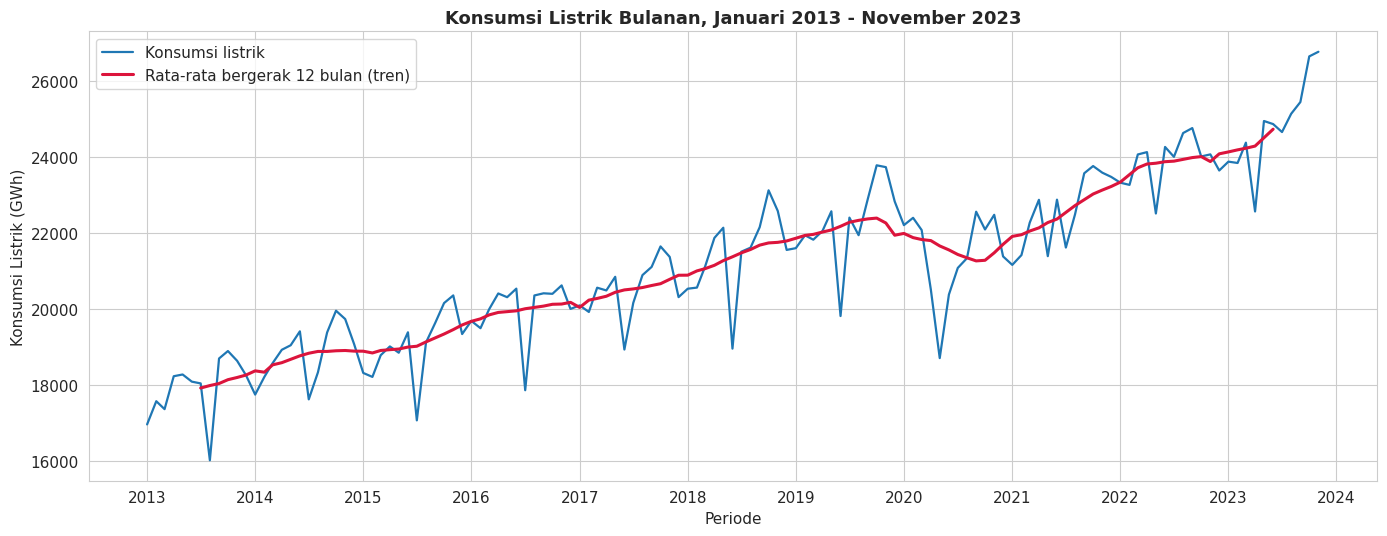

In [15]:
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(listrik.index, listrik.values, color='#1f77b4', lw=1.6, label='Konsumsi listrik')
ax.plot(listrik.index, listrik.rolling(12, center=True).mean(),
        color='crimson', lw=2.2, label='Rata-rata bergerak 12 bulan (tren)')

ax.set_title('Konsumsi Listrik Bulanan, Januari 2013 - November 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('Konsumsi Listrik (GWh)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout(); plt.show()

**Pertanyaan.** Berdasarkan plot deret di atas, apakah deret tampak stasioner? Komponen apa saja yang dapat Anda identifikasi?

**Interpretasi.** Deret menunjukkan **tren naik yang jelas dan konsisten** sepanjang periode amatan, sehingga nilai tengah deret **tidak konstan terhadap waktu**. Artinya deret **tidak stasioner dalam nilai tengah**. Selain itu terlihat pola naik-turun yang berulang setiap 12 bulan (indikasi **komponen musiman**) serta satu penurunan tajam pada pertengahan 2020 yang tidak mengikuti pola biasa.

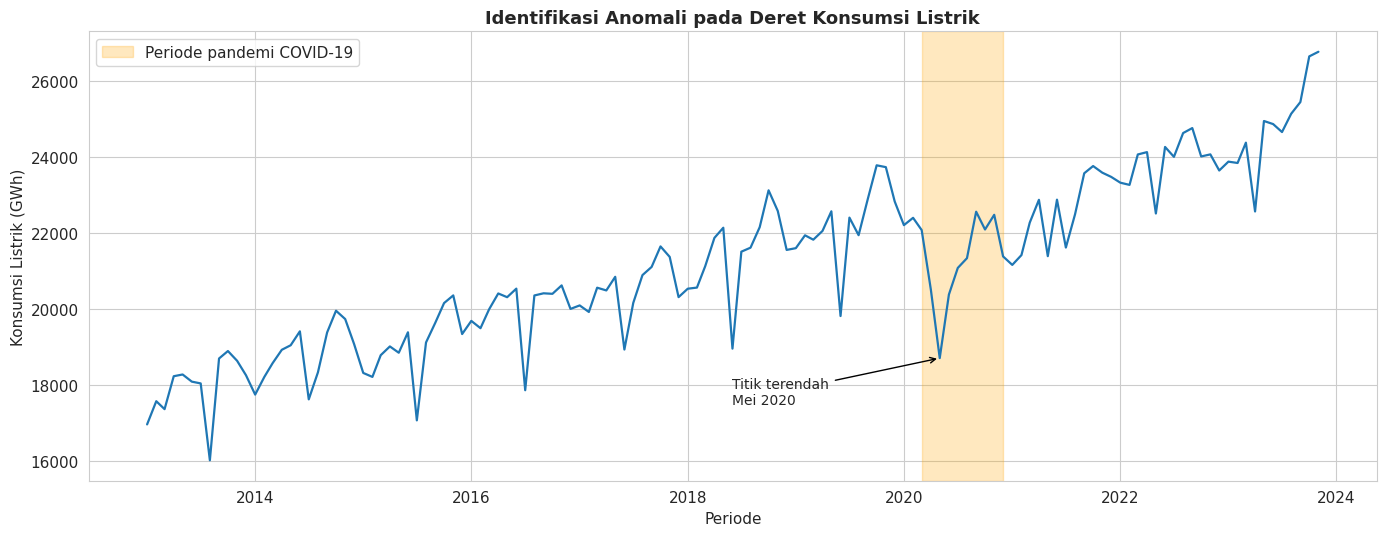

In [16]:
# menandai periode anomali (pandemi COVID-19)
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(listrik.index, listrik.values, color='#1f77b4', lw=1.6)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'),
           color='orange', alpha=0.25, label='Periode pandemi COVID-19')
ax.annotate('Titik terendah\nMei 2020', xy=(pd.Timestamp('2020-05-01'), 18704),
            xytext=(pd.Timestamp('2018-06-01'), 17500),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
ax.set_title('Identifikasi Anomali pada Deret Konsumsi Listrik', fontsize=13, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('Konsumsi Listrik (GWh)')
ax.legend(); plt.tight_layout(); plt.show()

### 4.2 Plot Musiman Bertumpuk (*Seasonal Plot*)

Plot ini menumpuk deret setiap tahun pada sumbu bulan yang sama sehingga pola musiman lebih mudah terlihat dibandingkan plot deret biasa.

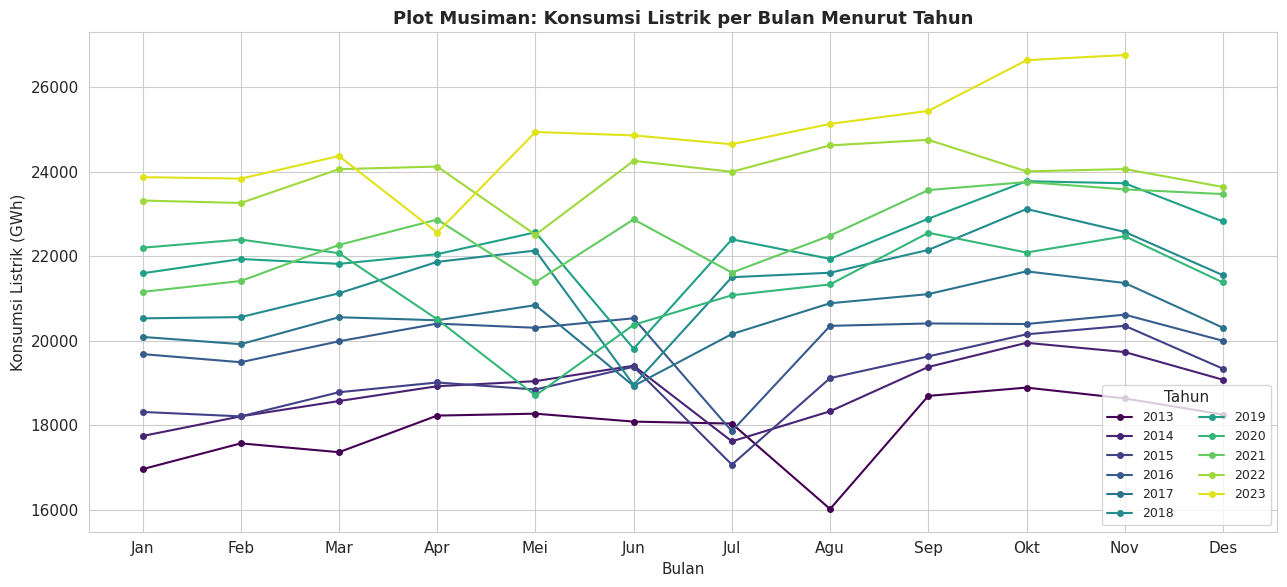

In [17]:
# menyusun data dalam bentuk matriks tahun x bulan
pivot = listrik.to_frame('listrik')
pivot['tahun'] = pivot.index.year
pivot['bulan'] = pivot.index.month
matriks = pivot.pivot_table(index='bulan', columns='tahun', values='listrik')

nama_bulan = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

fig, ax = plt.subplots(figsize=(13, 6))
warna = plt.cm.viridis(np.linspace(0, 0.95, matriks.shape[1]))
for i, th in enumerate(matriks.columns):
    ax.plot(matriks.index, matriks[th], marker='o', ms=4, color=warna[i], label=th)

ax.set_xticks(range(1, 13)); ax.set_xticklabels(nama_bulan)
ax.set_title('Plot Musiman: Konsumsi Listrik per Bulan Menurut Tahun',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Konsumsi Listrik (GWh)')
ax.legend(ncol=2, fontsize=9, title='Tahun', loc='lower right')
plt.tight_layout(); plt.show()

**Interpretasi.** Kurva antar tahun **hampir sejajar dan tersusun dari bawah ke atas** sesuai urutan tahun. Hal ini menegaskan dua hal sekaligus: (1) terdapat **tren naik** antartahun, dan (2) **pola musiman dalam satu tahun relatif serupa** dari tahun ke tahun. Konsumsi cenderung **melemah pada pertengahan tahun (Juni–Juli)** dan **memuncak pada Oktober–November**. Kurva tahun 2020 tampak "melenceng" dari pola umum akibat pandemi.

### 4.3 *Boxplot* Musiman dan Tahunan

*Boxplot* memisahkan dua sumber keragaman: keragaman **antartahun** (mencerminkan tren) dan keragaman **antarbulan** (mencerminkan musiman).

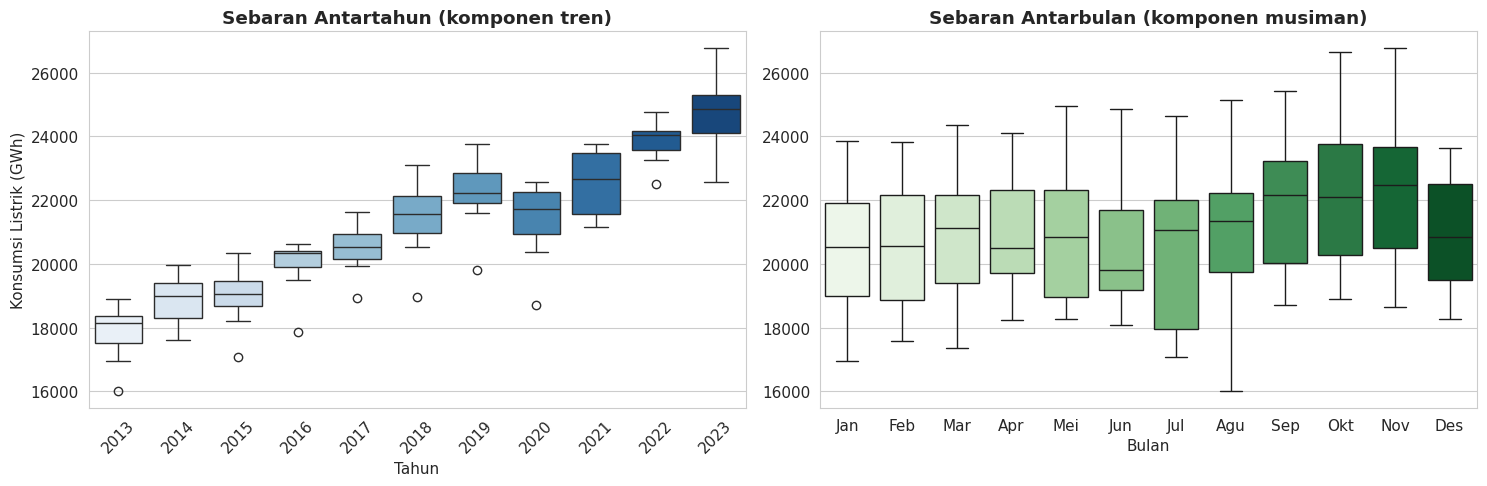

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=pivot['tahun'], y=pivot['listrik'], ax=ax[0], palette='Blues')
ax[0].set_title('Sebaran Antartahun (komponen tren)', fontweight='bold')
ax[0].set_xlabel('Tahun'); ax[0].set_ylabel('Konsumsi Listrik (GWh)')
ax[0].tick_params(axis='x', rotation=45)

sns.boxplot(x=pivot['bulan'], y=pivot['listrik'], ax=ax[1], palette='Greens')
ax[1].set_title('Sebaran Antarbulan (komponen musiman)', fontweight='bold')
ax[1].set_xlabel('Bulan'); ax[1].set_ylabel('')
ax[1].set_xticklabels(nama_bulan)

plt.tight_layout(); plt.show()

**Interpretasi.** *Boxplot* antartahun memperlihatkan **pergeseran median yang terus meningkat**, sebuah ciri khas deret dengan tren. *Boxplot* antarbulan masih bercampur dengan efek tren sehingga pola musiman belum terlalu tajam; pola musiman akan lebih jelas setelah tren dibuang (lihat *seasonal subseries plot* dan dekomposisi).

### 4.4 *Seasonal Subseries Plot* Setelah Penghilangan Tren

Untuk memisahkan efek musiman secara lebih bersih, deret dikurangi dengan tren (rata-rata bergerak terpusat 12 bulan) sehingga yang tersisa adalah komponen musiman dan sisaan.

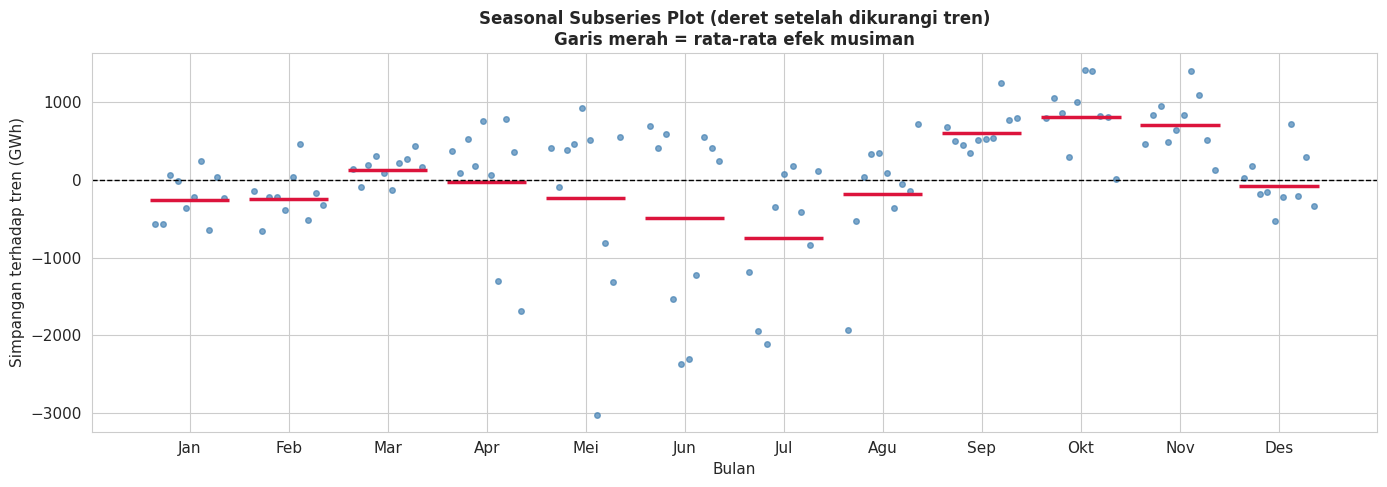

Indeks musiman aditif (GWh):
date
1    -260.9
2    -244.5
3     127.9
4     -19.3
5    -231.6
6    -486.7
7    -751.2
8    -183.0
9     605.0
10    814.4
11    702.0
12    -71.9


In [19]:
# menghilangkan tren dengan rata-rata bergerak terpusat 2x12
tren_ma = listrik.rolling(12, center=True).mean().rolling(2, center=True).mean()
detrend = (listrik - tren_ma).dropna()

indeks_musiman = detrend.groupby(detrend.index.month).mean()
indeks_musiman = indeks_musiman - indeks_musiman.mean()   # dinormalkan agar berjumlah nol

fig, ax = plt.subplots(figsize=(14, 5))
for b in range(1, 13):
    nilai = detrend[detrend.index.month == b]
    x = np.linspace(b - 0.35, b + 0.35, len(nilai))
    ax.plot(x, nilai.values, 'o', ms=4, color='steelblue', alpha=0.7)
    ax.hlines(indeks_musiman[b], b - 0.4, b + 0.4, color='crimson', lw=2.5)

ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(nama_bulan)
ax.set_title('Seasonal Subseries Plot (deret setelah dikurangi tren)\nGaris merah = rata-rata efek musiman',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Simpangan terhadap tren (GWh)')
plt.tight_layout(); plt.show()

print("Indeks musiman aditif (GWh):")
print(indeks_musiman.round(1).to_string())

**Interpretasi.** Setelah tren dibuang, pola musiman menjadi sangat tegas:

| Karakter | Bulan | Besaran |
|---|---|---|
| Puncak konsumsi | Oktober, November, September | sekitar **+605 s.d. +814 GWh** di atas tren |
| Lembah konsumsi | Juli, Juni | sekitar **−487 s.d. −751 GWh** di bawah tren |

Penurunan tajam pada **Juni–Juli** sangat masuk akal secara konteks: periode tersebut bertepatan dengan **libur sekolah dan libur Idulfitri**, ketika aktivitas industri, perkantoran, dan institusi pendidikan menurun. Sebaliknya **Oktober–November** merupakan puncak aktivitas produksi menjelang akhir tahun. Amplitudo musiman sekitar 1.500 GWh atau **±7% dari taraf deret**, sehingga komponen musiman **tidak dapat diabaikan** dalam pemodelan.

### 4.5 *Heatmap* Tahun × Bulan

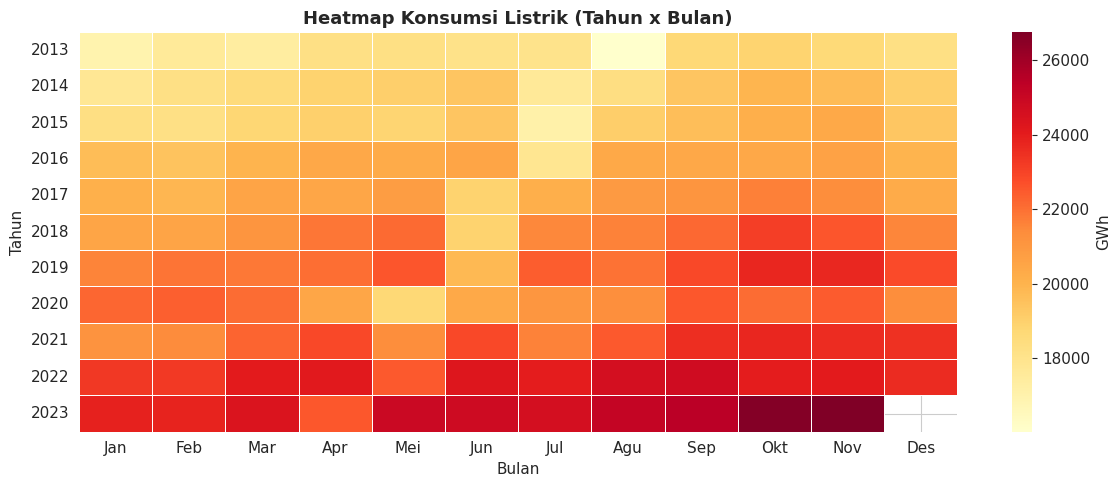

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(matriks.T, cmap='YlOrRd', annot=False, cbar_kws={'label': 'GWh'},
            linewidths=0.4, ax=ax)
ax.set_xticklabels(nama_bulan, rotation=0)
ax.set_title('Heatmap Konsumsi Listrik (Tahun x Bulan)', fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan'); ax.set_ylabel('Tahun')
plt.tight_layout(); plt.show()

**Interpretasi.** Gradasi warna yang **menggelap dari atas ke bawah** menunjukkan tren naik, sementara **kolom terang yang konsisten di sekitar Juni–Juli** menunjukkan lembah musiman. Kombinasi keduanya menegaskan bahwa deret memiliki komponen tren **dan** musiman secara bersamaan.

### 4.6 *Lag Plot*

*Lag plot* memplot $Y_t$ terhadap $Y_{t-k}$. Titik yang membentuk garis lurus dengan kemiringan positif menandakan autokorelasi yang kuat pada *lag* tersebut.

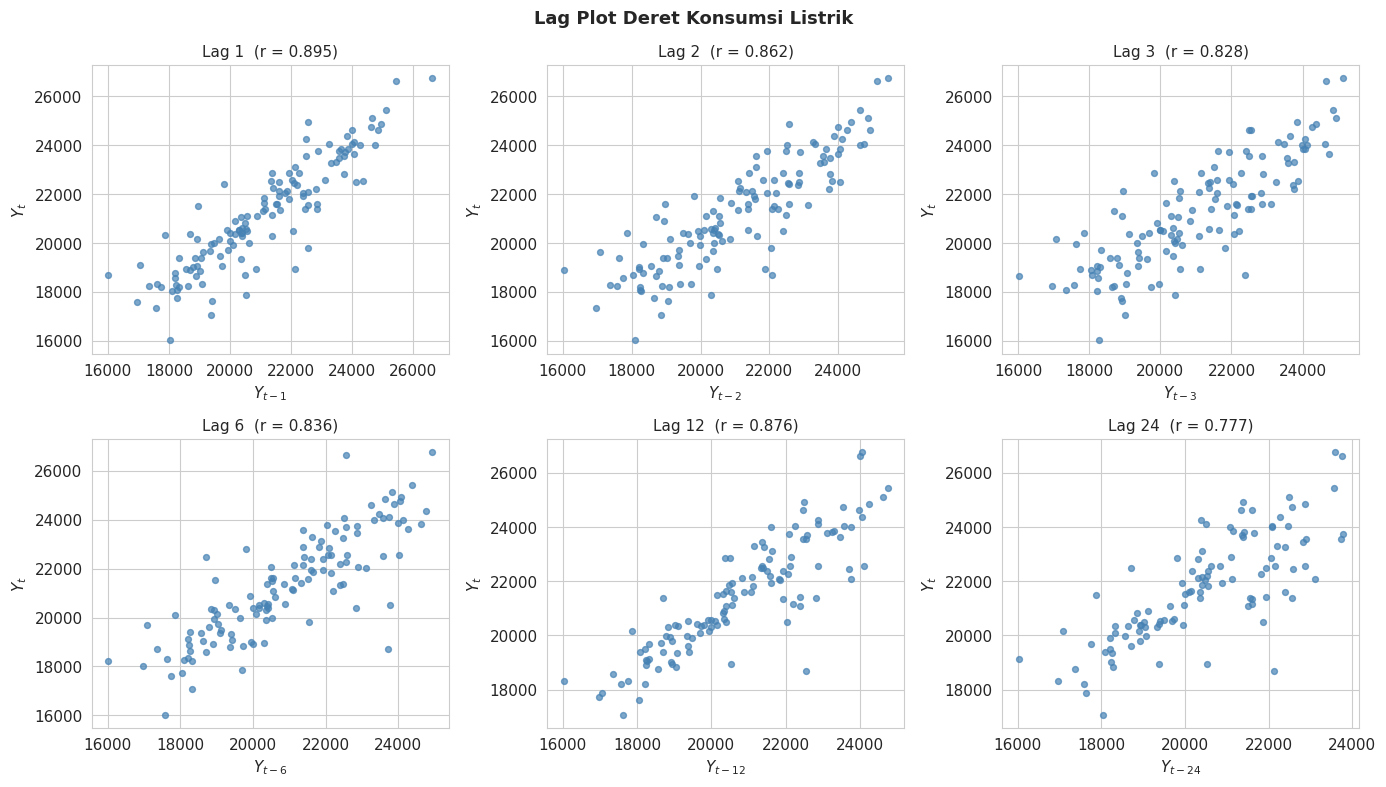

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, k in zip(axes.ravel(), [1, 2, 3, 6, 12, 24]):
    ax.scatter(listrik.shift(k), listrik, s=18, alpha=0.7, color='steelblue')
    r = listrik.corr(listrik.shift(k))
    ax.set_title(f'Lag {k}  (r = {r:.3f})', fontsize=11)
    ax.set_xlabel(f'$Y_{{t-{k}}}$'); ax.set_ylabel('$Y_t$')
plt.suptitle('Lag Plot Deret Konsumsi Listrik', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Interpretasi.** Pada seluruh *lag* yang ditampilkan, titik-titik masih membentuk pola **linear menaik yang rapat** — bahkan pada *lag* 24 (dua tahun) korelasinya masih tinggi. Autokorelasi yang **bertahan kuat pada *lag* yang jauh** adalah ciri khas deret **tidak stasioner**: nilai deret pada suatu waktu masih sangat ditentukan oleh nilai deret dua tahun sebelumnya.

## 5. Pemeriksaan Kestasioneran dalam Nilai Tengah

### 5.1 Plot ACF dan PACF Contoh

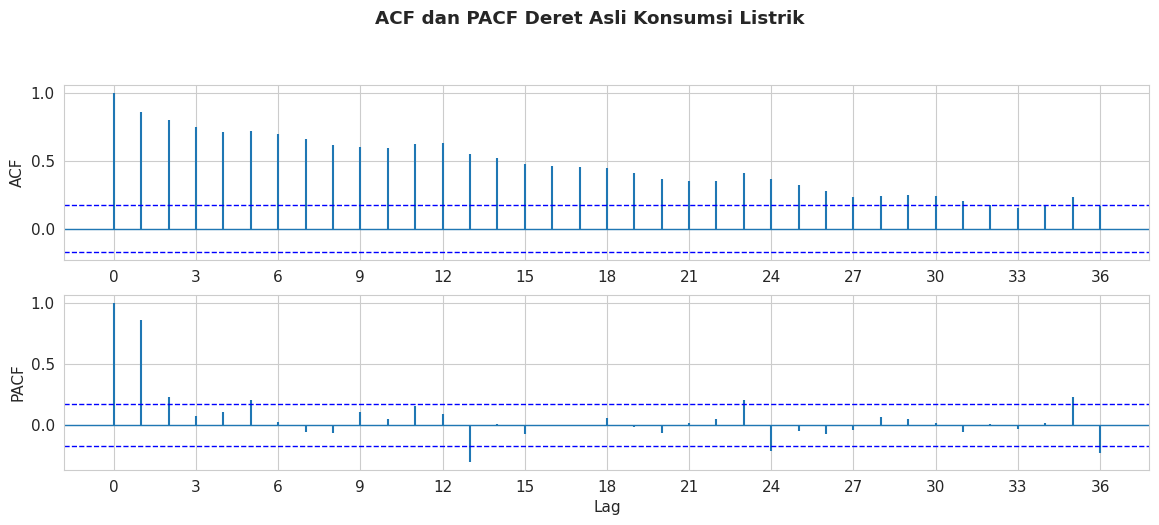

In [22]:
acf_pacf_fig(listrik, both=True, lag=36)
plt.suptitle('ACF dan PACF Deret Asli Konsumsi Listrik', y=1.03, fontweight='bold')
plt.show()

In [23]:
# nilai ACF dan PACF secara numerik
nilai_acf  = acf(listrik, nlags=24)
nilai_pacf = pacf(listrik, nlags=24, method='ywm')

tabel = pd.DataFrame({'lag': range(0, 25), 'ACF': nilai_acf, 'PACF': nilai_pacf}).set_index('lag')
tabel.round(3).T

lag,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
ACF,1.0,0.86,0.798,0.744,0.713,0.719,0.697,0.659,0.612,0.601,...,0.472,0.458,0.455,0.443,0.411,0.367,0.353,0.350,0.405,0.365
PACF,1.0,0.86,0.226,0.072,0.105,0.203,0.023,-0.058,-0.064,0.107,...,-0.074,-0.001,-0.002,0.059,-0.020,-0.069,0.013,0.049,0.205,-0.210


**Interpretasi.**

- **ACF** turun **sangat lambat** (*tails off slowly*): 0,860 pada *lag* 1; masih 0,630 pada *lag* 12; dan tetap sekitar 0,365 pada *lag* 24. Penurunan yang lambat dan bertahap seperti ini merupakan **tanda kuat ketidakstasioneran dalam nilai tengah**. Bandingkan dengan deret stasioner yang ACF-nya meluruh cepat menuju nol dalam beberapa *lag* saja.
- Terdapat **gelombang kecil di sekitar *lag* 12 dan 24** (nilai ACF sedikit naik kembali), yang merupakan jejak **komponen musiman tahunan**.
- **PACF** terpotong (*cuts off*) setelah *lag* 1 dengan nilai $\hat\phi_{11} = 0{,}860$ yang mendekati 1, lalu nilai-nilai berikutnya jauh mengecil. Nilai PACF *lag* 1 yang mendekati satu mengindikasikan adanya **akar satuan** (perilaku *random walk*), sehingga deret perlu dibedakan.

### 5.2 Uji Akar Satuan Augmented Dickey-Fuller (ADF)

Hipotesis uji ADF:

$H_0$ : deret **tidak stasioner** (terdapat akar satuan)

$H_1$ : deret **stasioner**

Kriteria keputusan: **tolak $H_0$ jika *p-value* < 0,05**.

In [24]:
def uji_adf(x, judul='', regression='c'):
    """Menampilkan ringkasan hasil uji ADF secara rapi."""
    x = pd.Series(np.asarray(x).ravel()).dropna()
    hasil = adfuller(x, autolag='AIC', regression=regression)
    print(f"=== Uji ADF : {judul} (regression='{regression}') ===")
    print(f"Statistik uji   : {hasil[0]:.4f}")
    print(f"p-value         : {hasil[1]:.4f}")
    print(f"Lag terpilih    : {hasil[2]}")
    print(f"Banyak amatan   : {hasil[3]}")
    print("Nilai kritis    :", {k: round(v, 3) for k, v in hasil[4].items()})
    putusan = "TOLAK H0  -> deret STASIONER" if hasil[1] < 0.05 else "TIDAK TOLAK H0 -> deret TIDAK STASIONER"
    print(f"Keputusan       : {putusan}\n")
    return hasil[1]

p_adf_asli = uji_adf(listrik, 'Deret asli', regression='c')
_          = uji_adf(listrik, 'Deret asli (dengan tren)', regression='ct')

=== Uji ADF : Deret asli (regression='c') ===
Statistik uji   : 0.3753
p-value         : 0.9805
Lag terpilih    : 12
Banyak amatan   : 118
Nilai kritis    : {'1%': np.float64(-3.487), '5%': np.float64(-2.886), '10%': np.float64(-2.58)}
Keputusan       : TIDAK TOLAK H0 -> deret TIDAK STASIONER

=== Uji ADF : Deret asli (dengan tren) (regression='ct') ===
Statistik uji   : -1.8969
p-value         : 0.6563
Lag terpilih    : 12
Banyak amatan   : 118
Nilai kritis    : {'1%': np.float64(-4.038), '5%': np.float64(-3.448), '10%': np.float64(-3.149)}
Keputusan       : TIDAK TOLAK H0 -> deret TIDAK STASIONER



**Interpretasi.** *p-value* uji ADF pada deret asli jauh di atas 0,05 (mendekati 1). Dengan demikian **$H_0$ tidak ditolak**, sehingga disimpulkan deret konsumsi listrik **tidak stasioner dalam nilai tengah**. Kesimpulan ini **konsisten** dengan hasil pembacaan plot deret (ada tren naik) maupun plot ACF (meluruh sangat lambat).

### 5.3 Uji KPSS

Uji KPSS memiliki hipotesis yang **berkebalikan** dengan ADF:

$H_0$ : deret **stasioner**

$H_1$ : deret **tidak stasioner**

Menggabungkan kedua uji ini merupakan praktik yang dianjurkan karena keduanya memiliki kekuatan (*power*) yang berbeda.

In [25]:
def uji_kpss(x, judul='', regression='c'):
    x = pd.Series(np.asarray(x).ravel()).dropna()
    stat, p, lags, crit = kpss(x, regression=regression, nlags='auto')
    print(f"=== Uji KPSS : {judul} (regression='{regression}') ===")
    print(f"Statistik uji   : {stat:.4f}")
    print(f"p-value         : {p:.4f}  (dibatasi pada rentang 0.01 - 0.10)")
    print(f"Lag terpilih    : {lags}")
    print("Nilai kritis    :", crit)
    putusan = "TOLAK H0 -> deret TIDAK STASIONER" if p < 0.05 else "TIDAK TOLAK H0 -> deret STASIONER"
    print(f"Keputusan       : {putusan}\n")
    return p

p_kpss_asli = uji_kpss(listrik, 'Deret asli', regression='c')
_            = uji_kpss(listrik, 'Deret asli (stasioner di sekitar tren)', regression='ct')

=== Uji KPSS : Deret asli (regression='c') ===
Statistik uji   : 1.8675
p-value         : 0.0100  (dibatasi pada rentang 0.01 - 0.10)
Lag terpilih    : 6
Nilai kritis    : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Keputusan       : TOLAK H0 -> deret TIDAK STASIONER

=== Uji KPSS : Deret asli (stasioner di sekitar tren) (regression='ct') ===
Statistik uji   : 0.1022
p-value         : 0.1000  (dibatasi pada rentang 0.01 - 0.10)
Lag terpilih    : 4
Nilai kritis    : {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
Keputusan       : TIDAK TOLAK H0 -> deret STASIONER



**Interpretasi.** Uji KPSS dengan `regression='c'` menolak $H_0$, yang berarti deret **tidak stasioner**. Hasil ini **sejalan** dengan uji ADF.

**Cara membaca kombinasi ADF dan KPSS:**

| ADF | KPSS | Kesimpulan |
|---|---|---|
| Tidak tolak $H_0$ | Tolak $H_0$ | Deret **tidak stasioner** (kasus data ini) |
| Tolak $H_0$ | Tidak tolak $H_0$ | Deret **stasioner** |
| Tolak $H_0$ | Tolak $H_0$ | Indikasi *heteroskedastisitas* atau tren deterministik |
| Tidak tolak $H_0$ | Tidak tolak $H_0$ | Data kurang informatif; perlu amatan lebih banyak |

### 5.4 Uji Phillips-Perron (PP) sebagai Pembanding

Uji PP menangani autokorelasi dan heteroskedastisitas pada galat secara nonparametrik, berbeda dengan ADF yang menambahkan *lag* selisih.

In [26]:
try:
    from arch.unitroot import PhillipsPerron
    pp = PhillipsPerron(listrik.dropna())
    print(pp.summary().as_text())
except Exception as e:
    print("Paket 'arch' belum terpasang. Jalankan: !pip install arch -q")
    print("Uji ADF dan KPSS di atas sudah memadai untuk keperluan eksplorasi.")

Paket 'arch' belum terpasang. Jalankan: !pip install arch -q
Uji ADF dan KPSS di atas sudah memadai untuk keperluan eksplorasi.


### 5.5 Pemeriksaan Visual: Rata-Rata dan Ragam Bergerak

Deret yang stasioner memiliki nilai tengah dan ragam yang **konstan terhadap waktu**. Hal ini dapat diperiksa secara visual melalui statistik bergerak.

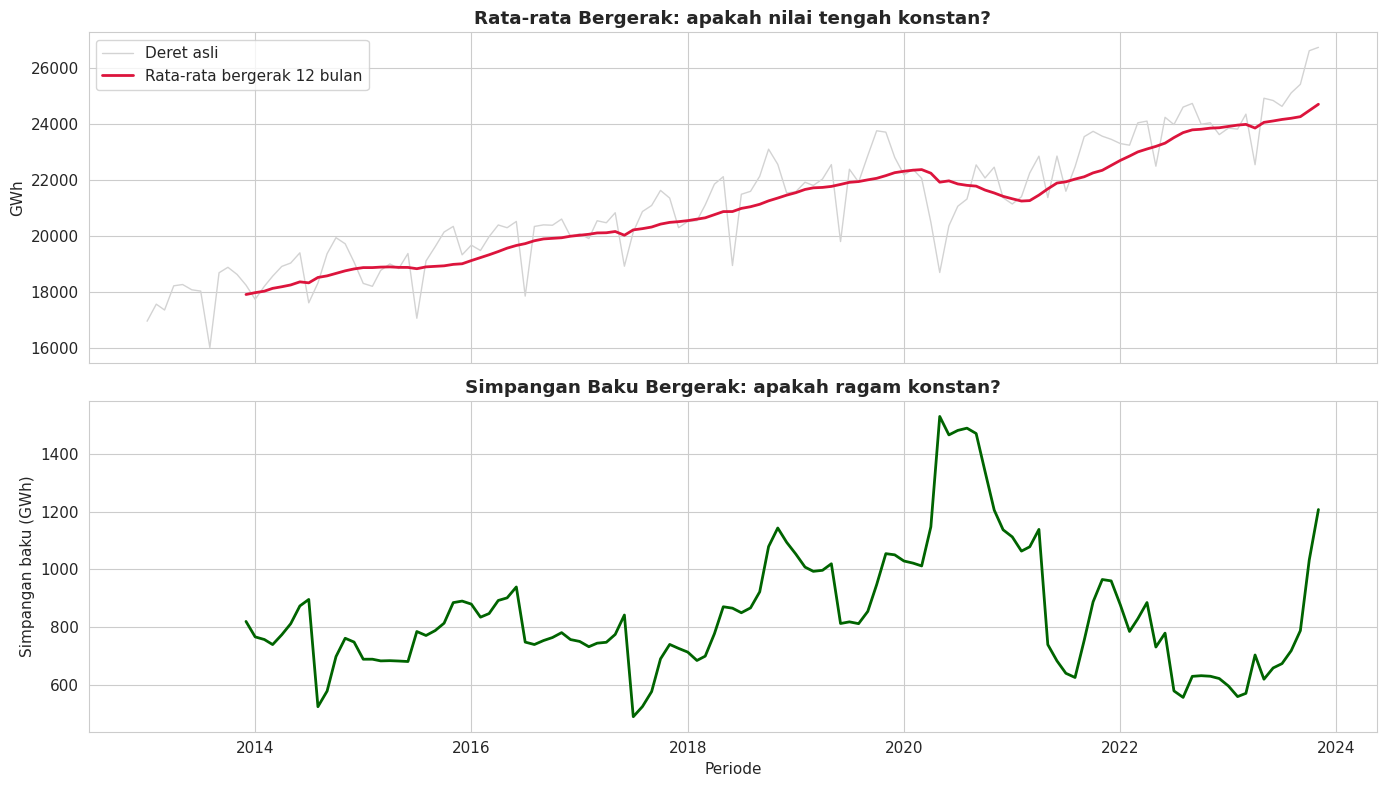

In [27]:
jendela = 12
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(listrik, color='lightgray', lw=1, label='Deret asli')
ax[0].plot(listrik.rolling(jendela).mean(), color='crimson', lw=2, label=f'Rata-rata bergerak {jendela} bulan')
ax[0].set_title('Rata-rata Bergerak: apakah nilai tengah konstan?', fontweight='bold')
ax[0].set_ylabel('GWh'); ax[0].legend()

ax[1].plot(listrik.rolling(jendela).std(), color='darkgreen', lw=2)
ax[1].set_title('Simpangan Baku Bergerak: apakah ragam konstan?', fontweight='bold')
ax[1].set_xlabel('Periode'); ax[1].set_ylabel('Simpangan baku (GWh)')

plt.tight_layout(); plt.show()

**Interpretasi.** Rata-rata bergerak **naik secara monoton**, menegaskan ketidakstasioneran dalam nilai tengah. Simpangan baku bergerak **berfluktuasi** tanpa pola naik yang tegas — ragam cenderung membesar pada periode 2018–2020 (terpengaruh anomali pandemi) lalu kembali normal. Ini merupakan petunjuk awal bahwa **masalah utama deret adalah nilai tengah, bukan ragam**.

## 6. Pemeriksaan Kestasioneran dalam Ragam (Transformasi Box-Cox)

Terdapat **dua jenis kestasioneran** dalam deret waktu, yaitu kestasioneran dalam **nilai tengah** dan dalam **ragam**. Uji ADF dan KPSS hanya menguji kestasioneran dalam nilai tengah. Kestasioneran dalam ragam diperiksa melalui **transformasi Box-Cox**:

$$g(x)=\frac{x^{\lambda}-1}{\lambda} \quad \text{untuk } \lambda \ne 0$$

$$g(x)=\log x \quad \text{untuk } \lambda = 0$$

**Kaidah keputusan:** jika $\lambda = 1$ atau angka 1 termuat dalam selang kepercayaan $\lambda$, deret dikatakan **sudah stasioner dalam ragam**.

Beberapa nilai $\lambda$ yang sering dijumpai:

| $\lambda$ | Transformasi |
|---|---|
| $-1$ | $1/x$ (kebalikan) |
| $-0{,}5$ | $1/\sqrt{x}$ |
| $0$ | $\log x$ |
| $0{,}5$ | $\sqrt{x}$ (akar kuadrat) |
| $1$ | tanpa transformasi |

Transformasi pangkat hanya berlaku untuk **data bernilai positif**. Pada data konsumsi listrik seluruh nilai sudah positif, sehingga tidak diperlukan penggeseran.

In [28]:
print("Nilai minimum deret:", listrik.min())
print("Apakah seluruh nilai positif?", bool((listrik > 0).all()))

Nilai minimum deret: 16018.31519
Apakah seluruh nilai positif? True


In [29]:
nilai_bc, lambda_fit, ci = boxcox(listrik, alpha=0.05)

print(f"Nilai lambda optimum         : {lambda_fit:.4f}")
print(f"Selang kepercayaan 95% lambda: ({ci[0]:.4f}, {ci[1]:.4f})")
print(f"Apakah 1 termuat dalam SK?   : {ci[0] <= 1 <= ci[1]}")

Nilai lambda optimum         : 0.2266
Selang kepercayaan 95% lambda: (-1.3048, 1.7648)
Apakah 1 termuat dalam SK?   : True


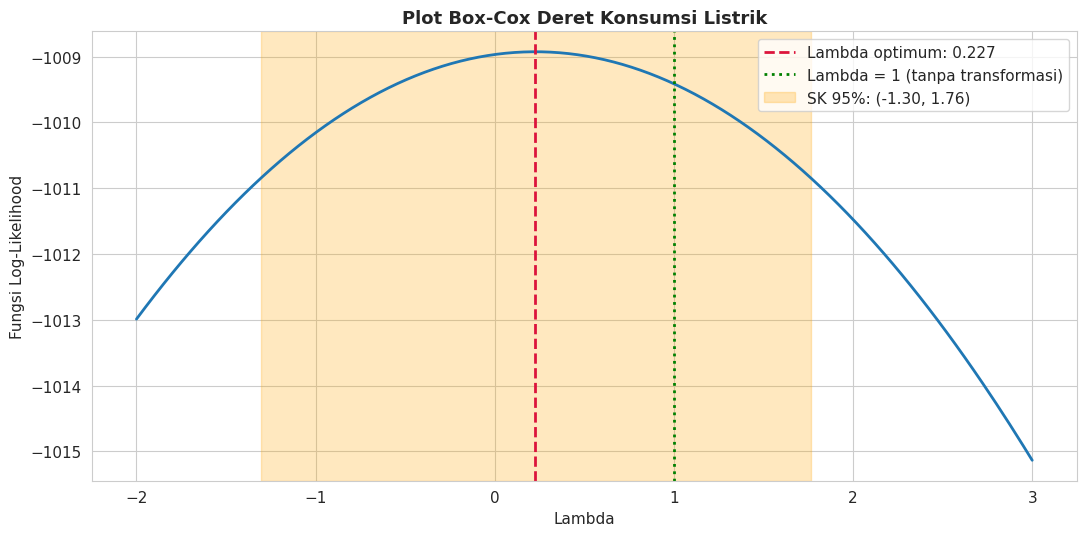

In [30]:
lambdas = np.linspace(-2, 3, 200)
llf = [boxcox_llf(l, listrik) for l in lambdas]

plt.figure(figsize=(11, 5.5))
plt.plot(lambdas, llf, color='#1f77b4', lw=2)
plt.axvline(lambda_fit, color='crimson', ls='--', lw=2,
            label=f'Lambda optimum: {lambda_fit:.3f}')
plt.axvline(1, color='green', ls=':', lw=2, label='Lambda = 1 (tanpa transformasi)')
plt.axvspan(ci[0], ci[1], color='orange', alpha=0.25,
            label=f'SK 95%: ({ci[0]:.2f}, {ci[1]:.2f})')
plt.xlabel('Lambda'); plt.ylabel('Fungsi Log-Likelihood')
plt.title('Plot Box-Cox Deret Konsumsi Listrik', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

**Interpretasi.** Nilai $\hat\lambda \approx 0{,}23$, namun **selang kepercayaan 95% sangat lebar dan memuat angka 1**. Karena angka 1 termuat dalam selang kepercayaan, secara formal disimpulkan bahwa deret **sudah stasioner dalam ragam** sehingga **transformasi Box-Cox tidak wajib dilakukan**.

**Catatan penting.** Selang kepercayaan yang sangat lebar di sini bukan tanpa sebab: uji Box-Cox mengasumsikan amatan saling bebas, padahal deret ini memiliki **tren yang sangat dominan**. Tren tersebut "menyerap" sebagian besar keragaman dan membuat pendugaan $\lambda$ menjadi tidak presisi. Oleh karena itu pemeriksaan kestasioneran ragam sebaiknya **diulang setelah tren dibuang** (lihat Bagian 8).

## 7. Dekomposisi Deret Waktu

Suatu deret waktu secara umum tersusun atas **komponen sistematik** dan **komponen non-sistematik**.

- **Komponen sistematik** bersifat konsisten dan berulang sehingga dapat dimodelkan; terdiri atas komponen **kecenderungan (trend)** dan **musiman (seasonality)**.
- **Komponen non-sistematik** merupakan komponen acak (**sisaan/*remainder***) yang tidak dapat dimodelkan secara langsung.

Dua bentuk model dekomposisi:

$$\text{Aditif:}\quad Y_t = T_t + S_t + e_t \qquad\qquad \text{Multiplikatif:}\quad Y_t = T_t \times S_t \times e_t$$

Model **aditif** dipilih bila amplitudo musiman **relatif tetap** meskipun taraf deret naik; model **multiplikatif** dipilih bila amplitudo musiman **ikut membesar** seiring naiknya taraf deret.

### 7.1 Dekomposisi Klasik Aditif

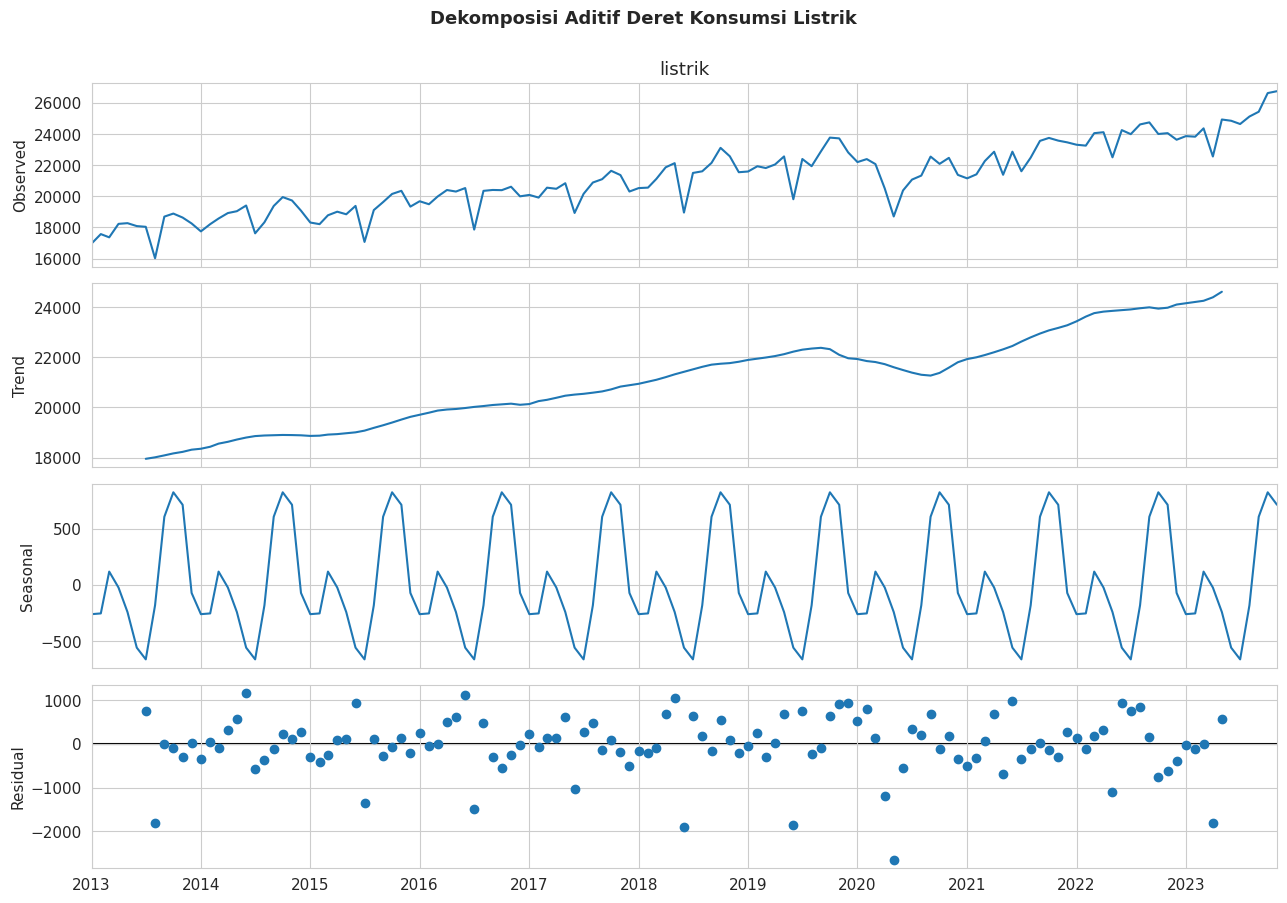

In [31]:
dekom_aditif = seasonal_decompose(listrik, model='additive', period=12)

fig = dekom_aditif.plot()
fig.set_size_inches(13, 9)
fig.axes[0].set_ylabel('Observed'); fig.axes[1].set_ylabel('Trend')
fig.axes[2].set_ylabel('Seasonal'); fig.axes[3].set_ylabel('Residual')
plt.suptitle('Dekomposisi Aditif Deret Konsumsi Listrik', y=1.00, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 7.2 Dekomposisi Klasik Multiplikatif

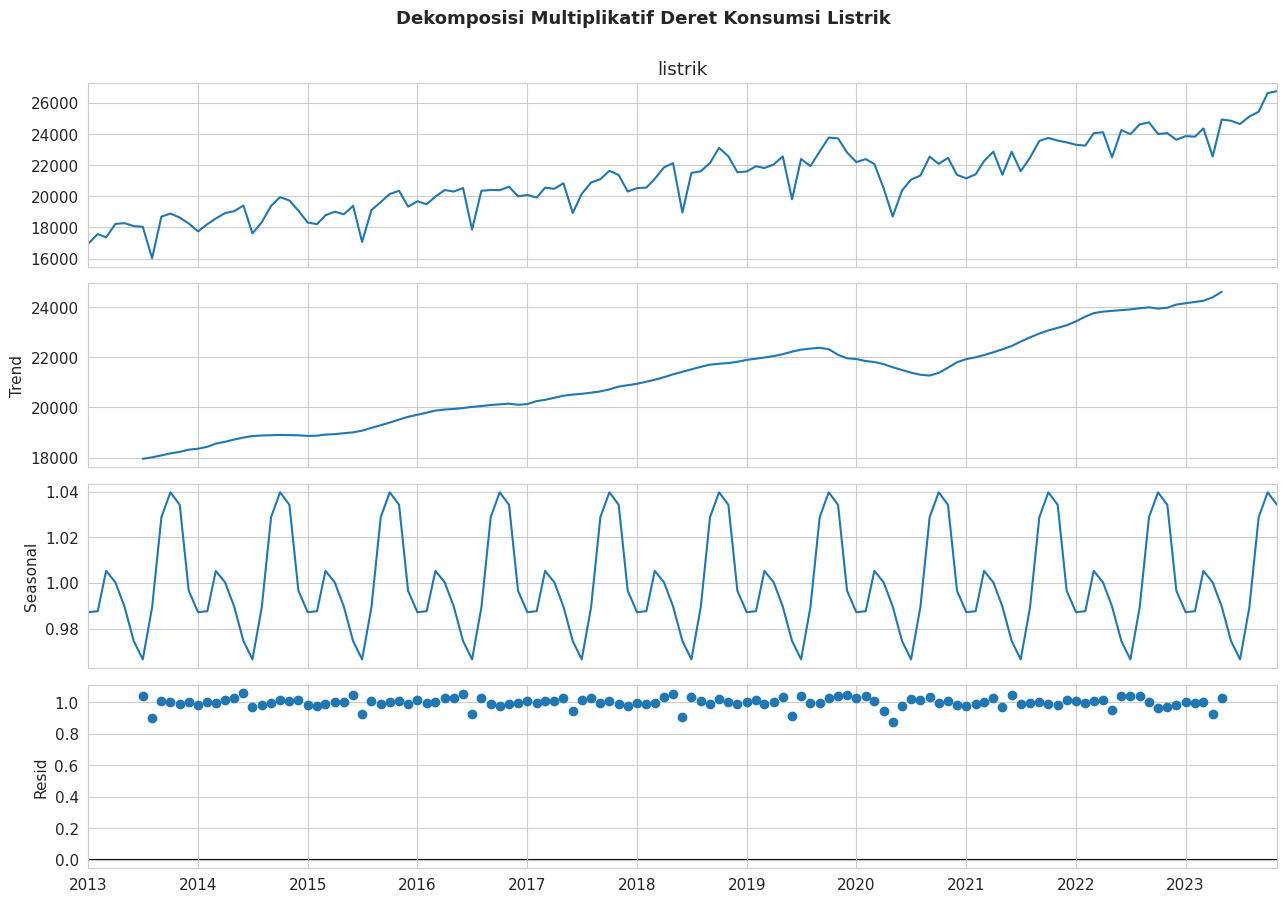

In [32]:
dekom_mult = seasonal_decompose(listrik, model='multiplicative', period=12)

fig = dekom_mult.plot()
fig.set_size_inches(13, 9)
plt.suptitle('Dekomposisi Multiplikatif Deret Konsumsi Listrik', y=1.00,
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [33]:
# membandingkan kedua model melalui keragaman sisaan
sisa_a = dekom_aditif.resid.dropna()
sisa_m = dekom_mult.resid.dropna()

print("Model ADITIF        -> simpangan baku sisaan relatif: "
      f"{sisa_a.std() / listrik.mean() * 100:.3f}%")
print("Model MULTIPLIKATIF -> simpangan baku sisaan relatif: "
      f"{sisa_m.std() * 100:.3f}%")

# memeriksa apakah amplitudo musiman membesar seiring taraf deret
amplitudo = pivot.groupby('tahun')['listrik'].agg(lambda s: s.max() - s.min())
taraf     = pivot.groupby('tahun')['listrik'].mean()
print(f"\nKorelasi antara taraf deret dan amplitudo musiman tahunan: "
      f"{np.corrcoef(taraf, amplitudo)[0, 1]:.3f}")

Model ADITIF        -> simpangan baku sisaan relatif: 3.109%
Model MULTIPLIKATIF -> simpangan baku sisaan relatif: 3.161%

Korelasi antara taraf deret dan amplitudo musiman tahunan: 0.331


**Interpretasi dekomposisi.**

1. **Komponen tren** naik hampir linear dari sekitar 18.000 GWh (2013) menuju sekitar 25.000 GWh (2023), dengan satu **pelandaian pada 2020** akibat pandemi. Inilah sumber utama ketidakstasioneran dalam nilai tengah.
2. **Komponen musiman** berulang secara teratur dengan periode 12 bulan dan amplitudo sekitar 1.500 GWh: lembah pada Juni–Juli, puncak pada Oktober–November.
3. **Komponen sisaan** berfluktuasi di sekitar nol (aditif) atau di sekitar satu (multiplikatif), dengan **lonjakan besar pada 2020** yang mencerminkan guncangan pandemi — guncangan ini memang tidak dapat dijelaskan oleh tren maupun musiman.
4. Korelasi antara taraf deret dan amplitudo musiman tidak kuat, sehingga **model aditif sudah memadai** untuk data ini.

### 7.3 Dekomposisi STL

STL (*Seasonal-Trend decomposition using Loess*) lebih lentur dibandingkan dekomposisi klasik karena memungkinkan **komponen musiman berubah perlahan** dari waktu ke waktu dan lebih tahan terhadap pencilan (seperti anomali 2020).

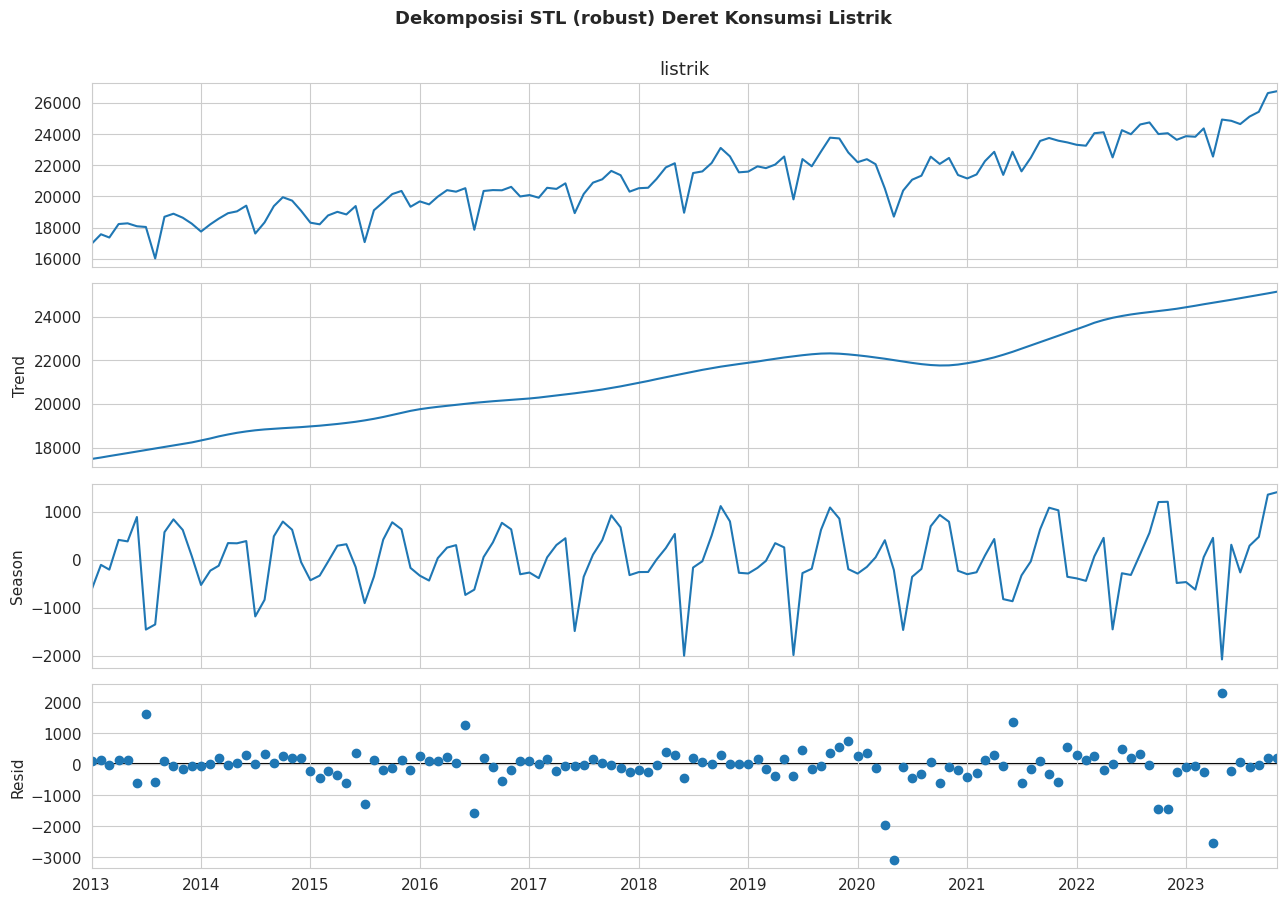

In [34]:
stl = STL(listrik, period=12, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(13, 9)
plt.suptitle('Dekomposisi STL (robust) Deret Konsumsi Listrik', y=1.00,
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [35]:
# kekuatan tren dan kekuatan musiman (Hyndman & Athanasopoulos)
sisa = stl.resid
kekuatan_tren    = max(0, 1 - sisa.var() / (stl.trend + sisa).var())
kekuatan_musiman = max(0, 1 - sisa.var() / (stl.seasonal + sisa).var())

print(f"Kekuatan tren    (F_T): {kekuatan_tren:.4f}")
print(f"Kekuatan musiman (F_S): {kekuatan_musiman:.4f}")
print("\nNilai mendekati 1 menandakan komponen tersebut sangat dominan.")

Kekuatan tren    (F_T): 0.9186
Kekuatan musiman (F_S): 0.4508

Nilai mendekati 1 menandakan komponen tersebut sangat dominan.


**Interpretasi.** Kekuatan tren yang sangat tinggi (mendekati 1) menegaskan bahwa **tren adalah komponen paling dominan** pada deret ini, diikuti komponen musiman yang juga nyata. Konsekuensinya, penanganan ketidakstasioneran **wajib** melibatkan pembedaan reguler, dan pemodelan lanjutan sebaiknya menggunakan model **SARIMA** (bukan ARIMA biasa) karena komponen musimannya kuat.

## 8. Penanganan Ketidakstasioneran

### 8.1 Pembedaan (*Differencing*)

Diberikan model AR(1) dengan $\phi = 1$:

$$Y_t = Y_{t-1} + e_t$$

**Pembedaan pertama** dinyatakan sebagai:

$$\Delta Y_t = Y_t - Y_{t-1} = e_t$$

Untuk deret musiman dengan periode $s$, digunakan **pembedaan musiman**:

$$\Delta_s Y_t = Y_t - Y_{t-s}$$

Berdasarkan eksplorasi sebelumnya, deret konsumsi listrik **tidak stasioner dalam nilai tengah** namun **sudah stasioner dalam ragam**. Karena itu penanganan difokuskan pada pembedaan.

#### 8.1.1 Pembedaan Reguler Ordo 1

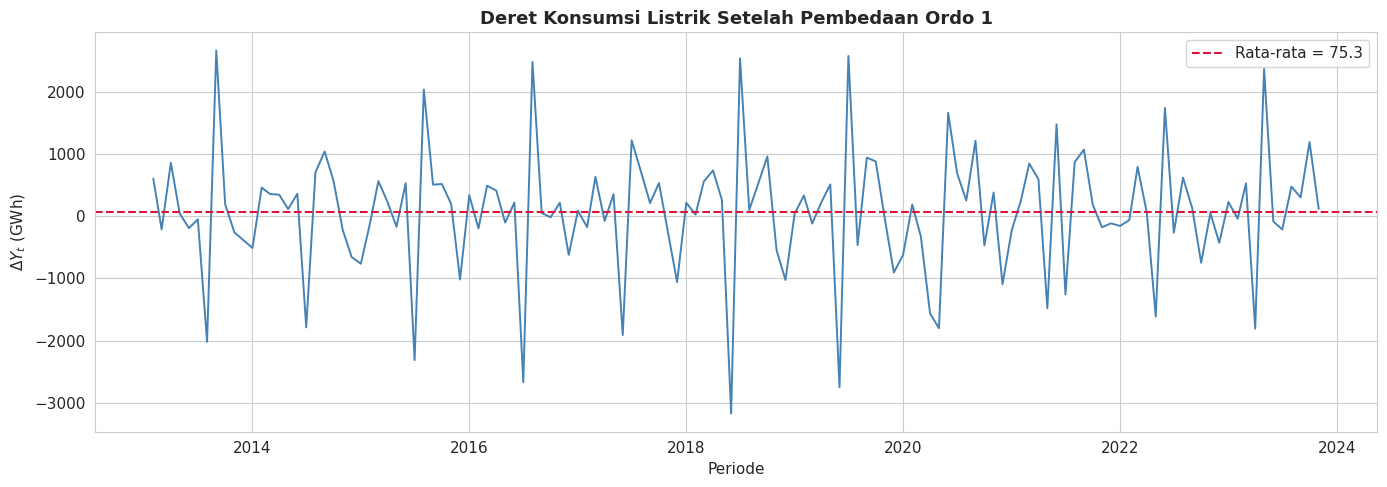

In [36]:
d1 = listrik.diff().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d1, color='steelblue', lw=1.4)
ax.axhline(d1.mean(), color='crimson', ls='--', lw=1.5,
           label=f'Rata-rata = {d1.mean():.1f}')
ax.set_title('Deret Konsumsi Listrik Setelah Pembedaan Ordo 1',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('$\\Delta Y_t$ (GWh)')
ax.legend(); plt.tight_layout(); plt.show()

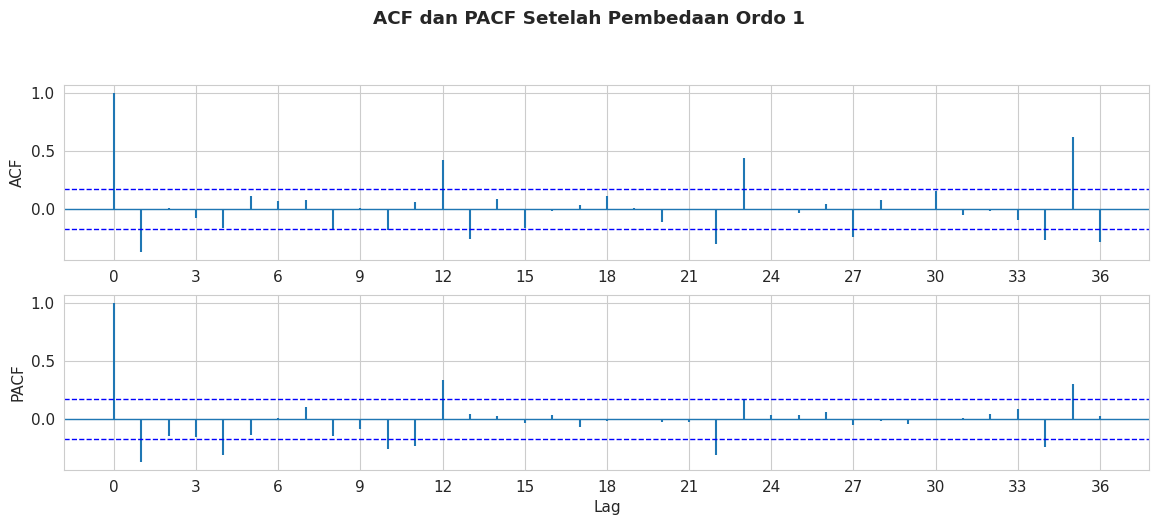

In [37]:
acf_pacf_fig(d1, both=True, lag=36)
plt.suptitle('ACF dan PACF Setelah Pembedaan Ordo 1', y=1.03, fontweight='bold')
plt.show()

In [38]:
p1 = uji_adf(d1, 'Pembedaan ordo 1')
k1 = uji_kpss(d1, 'Pembedaan ordo 1')

=== Uji ADF : Pembedaan ordo 1 (regression='c') ===
Statistik uji   : -3.8064
p-value         : 0.0028
Lag terpilih    : 11
Banyak amatan   : 118
Nilai kritis    : {'1%': np.float64(-3.487), '5%': np.float64(-2.886), '10%': np.float64(-2.58)}
Keputusan       : TOLAK H0  -> deret STASIONER

=== Uji KPSS : Pembedaan ordo 1 (regression='c') ===
Statistik uji   : 0.1101
p-value         : 0.1000  (dibatasi pada rentang 0.01 - 0.10)
Lag terpilih    : 10
Nilai kritis    : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Keputusan       : TIDAK TOLAK H0 -> deret STASIONER



**Interpretasi.** Plot deret hasil pembedaan pertama sudah **berfluktuasi di sekitar nilai tengah yang tetap (mendekati nol)** dan tidak lagi memperlihatkan tren. Uji ADF menghasilkan *p-value* < 0,05 (**tolak $H_0$**) dan uji KPSS menghasilkan *p-value* > 0,05 (**tidak tolak $H_0$**); keduanya sepakat bahwa deret **sudah stasioner dalam nilai tengah**.

Namun perhatikan plot ACF: masih terdapat **paku (*spike*) yang nyata pada *lag* 12 dan 24**. Artinya **pola musiman belum hilang** — pembedaan reguler hanya menghapus tren, bukan musiman.

#### 8.1.2 Pembedaan Musiman (Ordo 12)

Karena pola musiman masih tersisa, dilakukan pembedaan musiman terhadap deret asli.

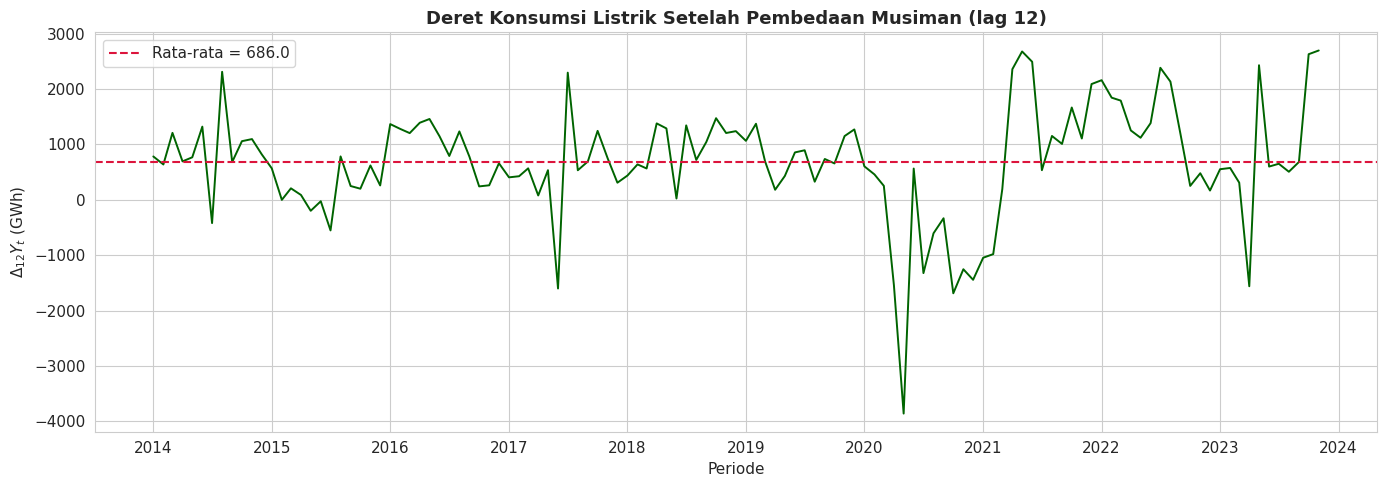

In [39]:
d12 = listrik.diff(12).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d12, color='darkgreen', lw=1.4)
ax.axhline(d12.mean(), color='crimson', ls='--', lw=1.5,
           label=f'Rata-rata = {d12.mean():.1f}')
ax.set_title('Deret Konsumsi Listrik Setelah Pembedaan Musiman (lag 12)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('$\\Delta_{12} Y_t$ (GWh)')
ax.legend(); plt.tight_layout(); plt.show()

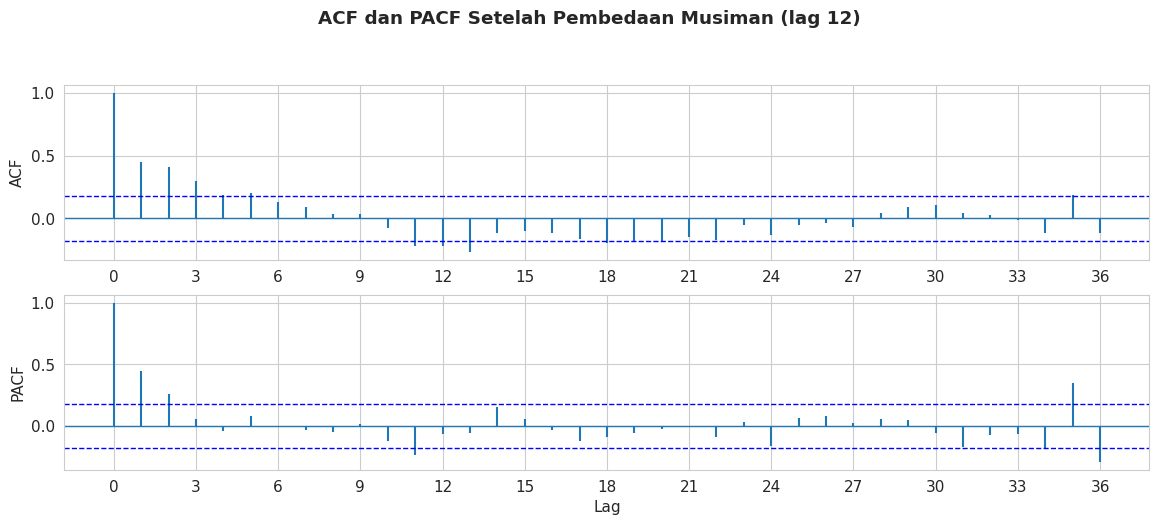

In [40]:
acf_pacf_fig(d12, both=True, lag=36)
plt.suptitle('ACF dan PACF Setelah Pembedaan Musiman (lag 12)', y=1.03, fontweight='bold')
plt.show()

In [41]:
_ = uji_adf(d12, 'Pembedaan musiman lag 12')
_ = uji_kpss(d12, 'Pembedaan musiman lag 12')

=== Uji ADF : Pembedaan musiman lag 12 (regression='c') ===
Statistik uji   : -3.8568
p-value         : 0.0024
Lag terpilih    : 1
Banyak amatan   : 117
Nilai kritis    : {'1%': np.float64(-3.488), '5%': np.float64(-2.887), '10%': np.float64(-2.58)}
Keputusan       : TOLAK H0  -> deret STASIONER

=== Uji KPSS : Pembedaan musiman lag 12 (regression='c') ===
Statistik uji   : 0.1062
p-value         : 0.1000  (dibatasi pada rentang 0.01 - 0.10)
Lag terpilih    : 5
Nilai kritis    : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Keputusan       : TIDAK TOLAK H0 -> deret STASIONER



#### 8.1.3 Kombinasi Pembedaan Reguler dan Musiman

Kombinasi $\Delta \Delta_{12} Y_t = (Y_t - Y_{t-1}) - (Y_{t-12} - Y_{t-13})$ menghapus tren **dan** musiman sekaligus. Kombinasi inilah yang lazim digunakan sebagai masukan model **SARIMA$(p,1,q)(P,1,Q)_{12}$**.

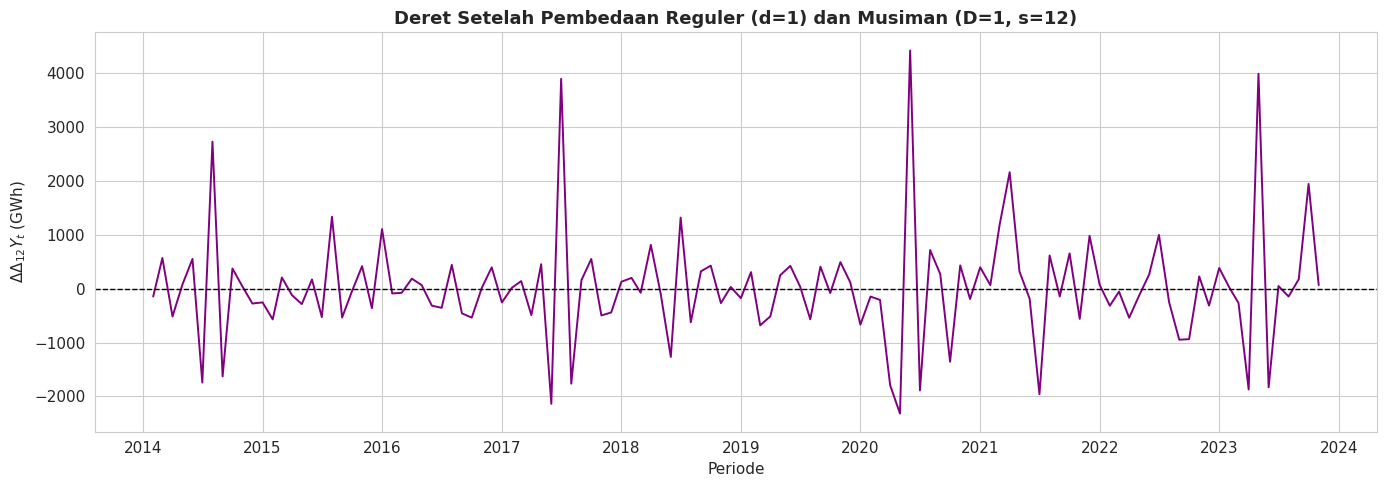

In [42]:
d1_12 = listrik.diff().diff(12).dropna()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d1_12, color='purple', lw=1.4)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_title('Deret Setelah Pembedaan Reguler (d=1) dan Musiman (D=1, s=12)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Periode'); ax.set_ylabel('$\\Delta\\Delta_{12} Y_t$ (GWh)')
plt.tight_layout(); plt.show()

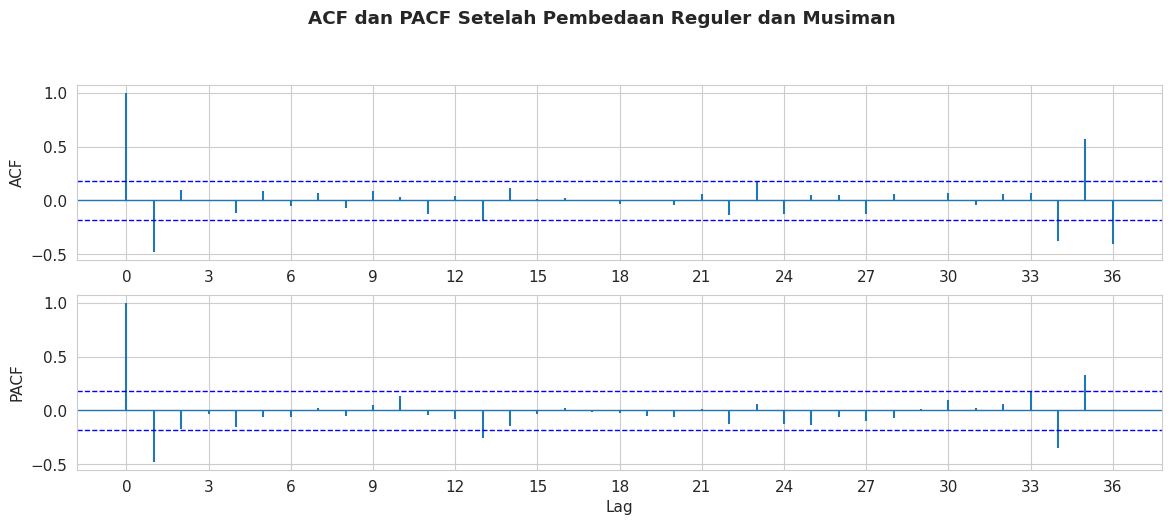

In [43]:
acf_pacf_fig(d1_12, both=True, lag=36)
plt.suptitle('ACF dan PACF Setelah Pembedaan Reguler dan Musiman',
             y=1.03, fontweight='bold')
plt.show()

In [44]:
_ = uji_adf(d1_12, 'Pembedaan d=1 dan D=1 (s=12)')
_ = uji_kpss(d1_12, 'Pembedaan d=1 dan D=1 (s=12)')

=== Uji ADF : Pembedaan d=1 dan D=1 (s=12) (regression='c') ===
Statistik uji   : -10.7499
p-value         : 0.0000
Lag terpilih    : 1
Banyak amatan   : 116
Nilai kritis    : {'1%': np.float64(-3.488), '5%': np.float64(-2.887), '10%': np.float64(-2.58)}
Keputusan       : TOLAK H0  -> deret STASIONER

=== Uji KPSS : Pembedaan d=1 dan D=1 (s=12) (regression='c') ===
Statistik uji   : 0.0824
p-value         : 0.1000  (dibatasi pada rentang 0.01 - 0.10)
Lag terpilih    : 9
Nilai kritis    : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Keputusan       : TIDAK TOLAK H0 -> deret STASIONER



**Interpretasi.** Setelah pembedaan reguler dan musiman, deret **berfluktuasi stabil di sekitar nol**, ACF **meluruh cepat** dan tidak lagi memperlihatkan paku musiman yang dominan, serta kedua uji akar satuan sepakat bahwa deret **sudah stasioner**. Deret ini siap digunakan untuk tahap **identifikasi model** pada pertemuan berikutnya.

### 8.2 Ringkasan Perbandingan Seluruh Tahap Penanganan

In [45]:
kandidat = {
    'Deret asli'                     : listrik,
    'Pembedaan ordo 1 (d=1)'         : d1,
    'Pembedaan musiman (D=1, s=12)'  : d12,
    'Pembedaan d=1 dan D=1 (s=12)'   : d1_12,
    'log(Y)'                         : np.log(listrik),
    'log(Y) dibedakan d=1 dan D=1'   : np.log(listrik).diff().diff(12).dropna(),
}

baris = []
for nama, deret in kandidat.items():
    deret = pd.Series(np.asarray(deret).ravel()).dropna()
    p_adf  = adfuller(deret, autolag='AIC')[1]
    p_kpss = kpss(deret, regression='c', nlags='auto')[1]
    baris.append({
        'Deret'          : nama,
        'n'              : len(deret),
        'Rata-rata'      : deret.mean(),
        'Simpangan baku' : deret.std(),
        'p-value ADF'    : p_adf,
        'p-value KPSS'   : p_kpss,
        'Kesimpulan'     : 'STASIONER' if (p_adf < 0.05 and p_kpss > 0.05) else 'belum stasioner',
    })

ringkasan_uji = pd.DataFrame(baris).set_index('Deret')
ringkasan_uji.round(4)

,n,Rata-rata,Simpangan baku,p-value ADF,p-value KPSS,Kesimpulan
Deret,,,,,,
Deret asli,131,21125.9282,2228.8968,0.9805,0.01,belum stasioner
Pembedaan ordo 1 (d=1),130,75.3378,1008.2157,0.0028,0.10,STASIONER
"Pembedaan musiman (D=1, s=12)",119,686.0010,1007.6659,0.0024,0.10,STASIONER
Pembedaan d=1 dan D=1 (s=12),118,16.2151,1046.5795,0.0000,0.10,STASIONER
log(Y),131,9.9527,0.1057,0.9554,0.01,belum stasioner
log(Y) dibedakan d=1 dan D=1,118,0.0005,0.0510,0.0000,0.10,STASIONER


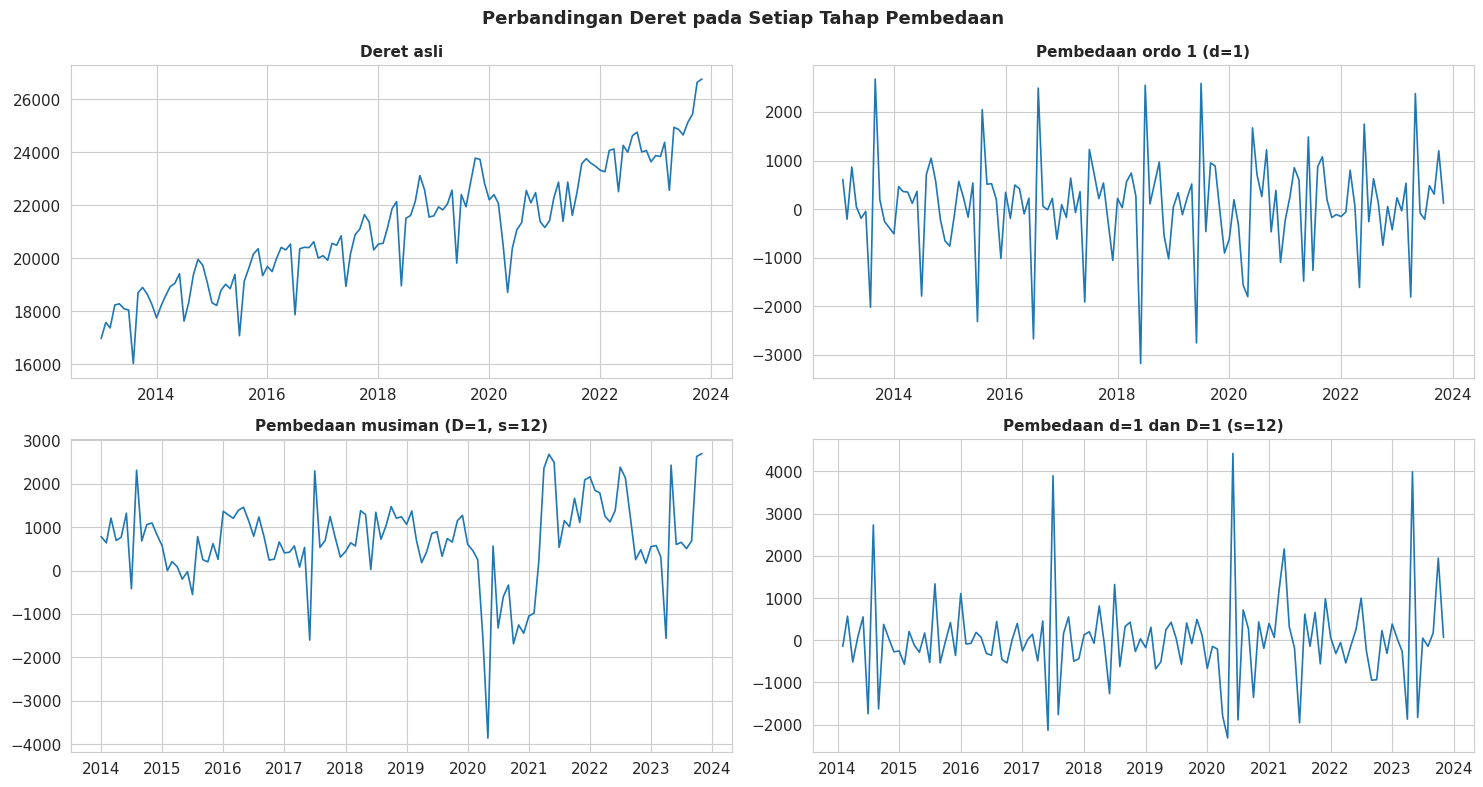

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (nama, deret) in zip(axes.ravel(),
        [(k, kandidat[k]) for k in ['Deret asli', 'Pembedaan ordo 1 (d=1)',
                                    'Pembedaan musiman (D=1, s=12)',
                                    'Pembedaan d=1 dan D=1 (s=12)']]):
    ax.plot(deret, lw=1.2)
    ax.set_title(nama, fontsize=11, fontweight='bold')
plt.suptitle('Perbandingan Deret pada Setiap Tahap Pembedaan',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 8.3 Pemeriksaan Ulang Kestasioneran Ragam Setelah Pembedaan

Sebagaimana dicatat pada Bagian 6, pendugaan $\lambda$ pada deret bertren bersifat kurang presisi. Pemeriksaan diulang pada deret hasil pembedaan (digeser agar seluruh nilainya positif) serta melalui perbandingan ragam antarsubperiode.

In [47]:
# menggeser agar seluruh nilai positif sebelum Box-Cox
d1_positif = d1 - d1.min() + 1
_, lam_d1, ci_d1 = boxcox(d1_positif, alpha=0.05)

print(f"Lambda deret hasil pembedaan : {lam_d1:.4f}")
print(f"Selang kepercayaan 95%       : ({ci_d1[0]:.4f}, {ci_d1[1]:.4f})")
print(f"Apakah 1 termuat dalam SK?   : {ci_d1[0] <= 1 <= ci_d1[1]}")

Lambda deret hasil pembedaan : 1.1330
Selang kepercayaan 95%       : (0.8707, 1.4306)
Apakah 1 termuat dalam SK?   : True


In [48]:
# perbandingan ragam antarsubperiode (paruh pertama vs paruh kedua)
paruh1, paruh2 = np.array_split(listrik.values, 2)
from scipy.stats import levene, bartlett

print("Ragam paruh pertama :", round(np.var(paruh1, ddof=1), 2))
print("Ragam paruh kedua   :", round(np.var(paruh2, ddof=1), 2))
print("\nUji Levene   -> p-value:", round(levene(paruh1, paruh2)[1], 4))
print("Uji Bartlett -> p-value:", round(bartlett(paruh1, paruh2)[1], 4))
print("\nJika p-value > 0.05, ragam kedua subperiode dapat dianggap homogen.")

Ragam paruh pertama : 1617298.48
Ragam paruh kedua   : 2281794.51

Uji Levene   -> p-value: 0.331
Uji Bartlett -> p-value: 0.1694

Jika p-value > 0.05, ragam kedua subperiode dapat dianggap homogen.


### 8.4 Urutan Penanganan: Transformasi Dahulu atau Pembedaan Dahulu?

> **Pertanyaan diskusi (dari notebook asli).** Jika deret tidak stasioner dalam nilai tengah **dan** ragam, manakah yang dilakukan lebih dahulu: *differencing* lalu Box-Cox, atau Box-Cox lalu *differencing*?

**Jawaban: transformasi Box-Cox dilakukan terlebih dahulu, baru kemudian pembedaan.** Alasannya:

1. **Transformasi pangkat memerlukan data bernilai positif.** Hasil pembedaan pasti memuat nilai negatif, sehingga Box-Cox tidak dapat diterapkan secara langsung dan memerlukan penggeseran yang bersifat sembarang (*arbitrary*) serta mengubah tafsiran $\lambda$.
2. **Pembedaan tidak menghilangkan ketidakstasioneran ragam.** Bila ragam membesar seiring taraf deret, sifat tersebut akan **terbawa** ke dalam deret hasil pembedaan.
3. **Sebaliknya, transformasi Box-Cox menstabilkan ragam tanpa merusak struktur autokorelasi**, sehingga pembedaan setelahnya bekerja pada deret yang ragamnya sudah homogen.
4. Urutan ini pula yang dianut prosedur baku pemodelan **ARIMA/SARIMA**: *transformasi → pembedaan → identifikasi orde → pendugaan parameter → diagnostik*.

**Untuk data konsumsi listrik ini**, karena angka 1 termuat dalam selang kepercayaan $\lambda$, transformasi Box-Cox **tidak diperlukan**; cukup dilakukan pembedaan reguler dan musiman.

## 9. Ringkasan Hasil Eksplorasi

| Aspek | Temuan |
|---|---|
| Periode dan banyak amatan | Jan 2013 – Nov 2023; 131 amatan bulanan |
| *Missing value* / duplikat | Tidak ada |
| Rentang nilai | 16.018 – 26.755 GWh (rata-rata 21.126 GWh) |
| Tren | Naik kuat, sekitar **+3,3% per tahun** |
| Musiman | Periode 12 bulan; puncak **Okt–Nov**, lembah **Jun–Jul**; amplitudo sekitar ±7% |
| Anomali | Penurunan tajam **Apr–Mei 2020** (pandemi COVID-19) |
| ACF deret asli | Meluruh sangat lambat, terdapat gelombang musiman pada *lag* 12 dan 24 |
| PACF deret asli | Terpotong setelah *lag* 1 dengan nilai mendekati 1 (indikasi akar satuan) |
| Uji ADF deret asli | *p-value* > 0,05 → **tidak stasioner** dalam nilai tengah |
| Uji KPSS deret asli | *p-value* < 0,05 → **tidak stasioner**, konsisten dengan ADF |
| Box-Cox | $\hat\lambda \approx 0{,}23$ dengan SK memuat 1 → **sudah stasioner dalam ragam** |
| Dekomposisi | Model **aditif** memadai; tren merupakan komponen dominan |
| Penanganan | Pembedaan reguler $d=1$ **dan** pembedaan musiman $D=1$ ($s=12$) |
| Model lanjutan yang disarankan | **SARIMA$(p,1,q)(P,1,Q)_{12}$** |

## 10. Latihan dan Pertanyaan Diskusi

1. Berdasarkan plot ACF dan PACF deret hasil pembedaan $d=1$ dan $D=1$, orde $p, q, P, Q$ berapa yang Anda usulkan untuk model SARIMA? Jelaskan alasannya.
2. Mengapa uji ADF dan uji KPSS perlu dijalankan bersama-sama? Apa yang Anda simpulkan bila keduanya sama-sama menolak $H_0$?
3. Bandingkan hasil dekomposisi klasik dan STL pada komponen sisaan tahun 2020. Mengapa STT dengan opsi `robust=True` lebih sesuai untuk data yang memuat pencilan?
4. Apakah penggunaan pembedaan musiman saja (tanpa pembedaan reguler) sudah cukup untuk menstasionerkan deret ini? Dukung jawaban Anda dengan hasil uji pada Bagian 8.2.
5. Anomali pandemi 2020 dapat ditangani melalui peubah boneka (*dummy*) intervensi. Bagaimana pengaruhnya terhadap pendugaan komponen tren dan musiman?
6. Amati pola lembah pada Juni–Juli. Menurut Anda, apakah tanggal Idulfitri yang bergeser setiap tahun dapat menyebabkan pola musiman yang **tidak tetap** (*moving holiday effect*)? Bagaimana cara menanganinya?

### Sel Latihan Mandiri

In [49]:
# Silakan gunakan sel ini untuk mengerjakan latihan